In [46]:
#importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

#ML libraries
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

In [48]:
#Load dataset 
df = pd.read_csv('delhi_ncr_rainfall.csv')

Step1 : Get overview on your data

1. `df.head()`: Displays the first few rows (default 5) of the DataFrame.
2. `df.shape`: Returns a tuple representing the dimensionality (rows, columns) of the DataFrame.
3. `df.info()`: Provides a concise summary of the DataFrame, including data types, non-null values, and memory usage.
4. `df.describe().T`: Generates summary statistics (count, mean, std, min, 25%, 50%, 75%, max) for numeric columns, transposed for easier reading.

In [55]:
df.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1011.973170,18.745401,15.200201,11.655000,11.592164,81,38,no,0.999749,165.329601,11.674172
1,2,1014.439975,16.428668,12.992444,9.556219,5.330913,61,29,no,1.818250,66.025624,11.084845
2,3,1012.237058,20.247564,14.135590,8.023615,7.882965,68,27,no,2.327713,32.618316,17.367720
3,4,1017.198808,18.824620,15.353618,11.882616,10.154195,74,6,no,0.650516,341.598793,24.312641
4,5,1013.684661,23.083973,15.108135,7.132296,7.694168,62,6,no,8.331949,62.411275,12.821212


In [53]:
df.shape

(365, 12)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   day            365 non-null    int64  
 1   pressure       365 non-null    float64
 2   maxtemp        365 non-null    float64
 3   temparature    365 non-null    float64
 4   mintemp        365 non-null    float64
 5   dewpoint       365 non-null    float64
 6   humidity       365 non-null    int64  
 7   cloud          365 non-null    int64  
 8   rainfall       365 non-null    object 
 9   sunshine       365 non-null    float64
 10  winddirection  365 non-null    float64
 11  windspeed      365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.3+ KB


In [26]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,365.0,183.000000,105.510663,1.000000,92.000000,183.000000,274.000000,365.000000
pressure,365.0,1009.915973,5.848690,1000.010408,1004.545393,1010.516252,1014.815372,1019.925246
maxtemp,365.0,31.763599,8.066505,15.153045,25.169477,33.065893,37.013206,47.934010
temparature,365.0,25.601291,7.217345,11.012906,19.903398,28.338069,31.079958,38.815764
mintemp,365.0,19.438982,7.221834,5.038655,12.246320,20.970479,25.675173,29.967066
dewpoint,365.0,17.503483,6.714059,3.587050,11.976734,16.607980,23.511291,30.632285
humidity,365.0,59.016438,21.888824,20.000000,40.000000,59.000000,79.000000,94.000000
cloud,365.0,26.276712,20.977032,0.000000,11.000000,22.000000,35.000000,97.000000
sunshine,365.0,4.492434,2.978302,0.050430,1.946391,3.796583,7.328015,9.840835
winddirection,365.0,185.878751,104.078633,0.443461,90.910002,189.460246,278.580428,357.890170


### Step 2 : Check for missing values
    
1. `df.isnull().sum()`
    - This shows the count of missing values in each column.

2. *Handle missing values*:
    - *Drop rows with missing values*: `df.dropna()`
    - *Fill with mean/median*: `df.fillna(df.mean())` (for numerical columns)
    - *Fill with specific value*: `df.fillna('value')`
    - *Forward/backward fill*: `df.fillna(method='ffill')` or `df.fillna(method='bfill')`

3. *Check data types*: `df.dtypes`
    - Ensure columns have the correct data type.

In [56]:
df.isnull().sum()

day              0
pressure         0
maxtemp          0
temparature      0
mintemp          0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [57]:
df.columns

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')

Removing leading/trailing whitespace from column names and correcting a column name typo.

In [118]:
df.rename(str.strip,axis='columns',inplace=True)

#renamed temperature column since its spelled wrong
df.rename(columns={'temparature':'temperature'},inplace=True)
print(df.columns)

Index(['day', 'pressure', 'temperature', 'dewpoint', 'humidity', 'cloud',
       'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')


We apply Label Encoding to 'object' dtype columns as they typically contain categorical data. 

This conversion enables machine learning models to process the data.

In [71]:
# Identify columns with dtype 'object'
object_columns = df.select_dtypes(include=['object']).columns

print(object_columns)

# Loop through and print unique values for each
for col in object_columns:
    print(f"Column: {col}")
    print(f"Unique Values: {df[col].unique()}")

Index(['rainfall'], dtype='object')
Column: rainfall
Unique Values: ['no' 'yes']


In [79]:
df['rainfall'].replace({'yes':1, 'no':0}, inplace=True)
print(df['rainfall'].unique())

[0 1]


In [80]:
print(df['rainfall'].value_counts())

0    305
1     60
Name: rainfall, dtype: int64


#### Filling missing values with column mean
This replaces null values in each column with the column's average, suitable for numerical data.

In [119]:
df.isnull().sum()

day              0
pressure         0
temperature      0
dewpoint         0
humidity         0
cloud            0
rainfall         0
sunshine         0
winddirection    0
windspeed        0
dtype: int64

In [73]:
for col in df.columns:
    """Checking if the column contains any null values
    then fill with mean(avg) of that particular column"""
    if df[col].isnull().sum() > 0:
        fill_avg_val = df[col].mean() 
        df[col] = df[col].fillna(fill_avg_val)

print(df.isnull().sum().sum())

0


### Step 3 : Data Visualization

We use data visualization techniques like pie charts, distplots, and box plots to:

1. *Understand data distribution*: Visualize how data is spread out and identify patterns or outliers.
2. *Identify trends and correlations*: Spot relationships between variables and trends in the data.
3. *Communicate insights effectively*: Present complex data in a simple, intuitive way to both technical and non-technical audiences.

These visualizations help us explore, analyze, and share data insights more effectively. 📊

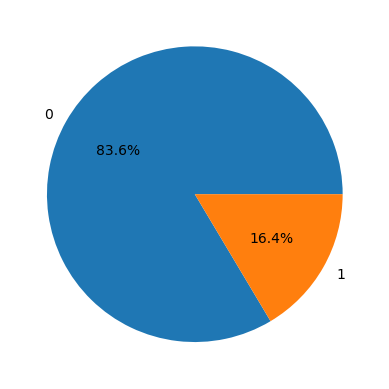

In [82]:
plt.pie(df['rainfall'].value_counts().values,
        labels = df['rainfall'].value_counts().index,
        autopct='%1.1f%%')
plt.show()

In [32]:
df.groupby('rainfall').mean()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
rainfall,,,,,,,,,,,
no,174.242623,1009.860333,31.543436,25.017699,18.491963,16.169817,55.281967,22.455738,4.960977,182.871065,14.927025
yes,227.516667,1010.198811,32.882764,28.567880,24.252995,24.282947,78.000000,45.700000,2.110674,201.167820,14.854536


In [85]:
#this step is done to include features to plot distplot 
features = list(df.select_dtypes(include = np.number).columns)
features.remove('day')
print(features)

['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection', 'windspeed']


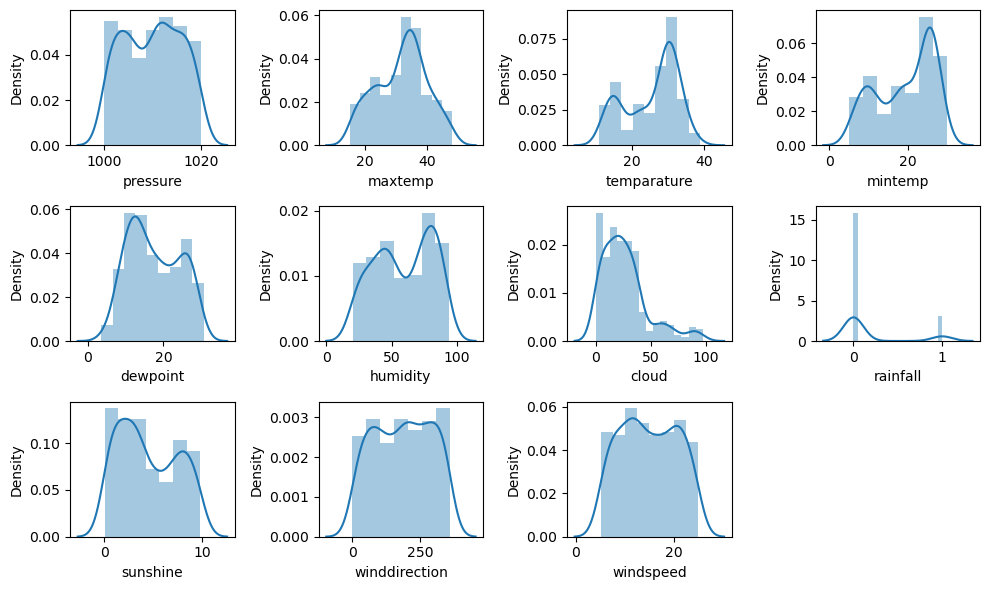

In [86]:
plt.subplots(figsize=(10,6))

for i, col in enumerate(features):
    plt.subplot(3,4, i + 1)
    sn.distplot(df[col])
    
plt.tight_layout()
plt.show()

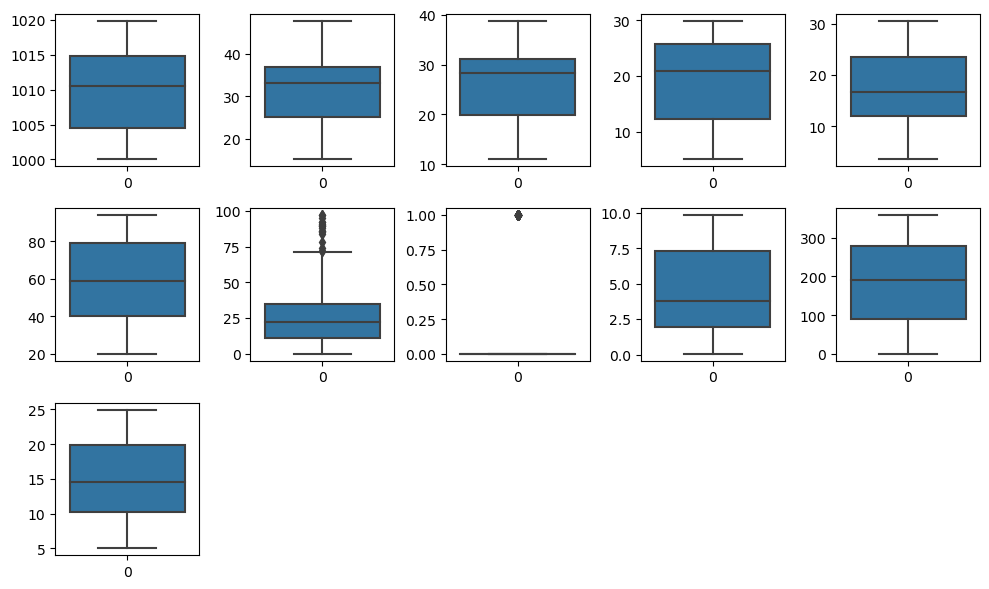

In [89]:
plt.subplots(figsize=(10,6))

for i, col in enumerate(features):
    plt.subplot(3,5, i + 1)
    sn.boxplot(df[col])
plt.tight_layout()
plt.show()

### Step 4 : Feature Selection
    We remove highly correlated features to avoid multicollinearity and improve model stability. Redundant features (like 'day') are removed based on:
- Feature importance
- Business context
- Correlation analysis

In [91]:
df.corr()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
day,1.000000,-0.013928,-0.073718,-0.029526,0.023326,0.092715,0.190427,0.145566,0.187391,-0.063480,-0.026424,0.020620
pressure,-0.013928,1.000000,-0.035282,-0.011457,0.016509,0.004368,0.025840,0.049497,0.021478,-0.063615,-0.028979,0.051401
maxtemp,-0.073718,-0.035282,1.000000,0.950183,0.782224,0.680876,-0.522135,0.106560,0.061621,-0.040293,0.013068,-0.014789
temparature,-0.029526,-0.011457,0.950183,1.000000,0.937439,0.804696,-0.414371,0.222641,0.182558,-0.074672,0.021093,-0.018968
mintemp,0.023326,0.016509,0.782224,0.937439,1.000000,0.847881,-0.245021,0.325982,0.296061,-0.104245,0.027564,-0.021393
dewpoint,0.092715,0.004368,0.680876,0.804696,0.847881,1.000000,0.206823,0.466038,0.448468,-0.214516,0.027707,-0.008639
humidity,0.190427,0.025840,-0.522135,-0.414371,-0.245021,0.206823,1.000000,0.347356,0.385192,-0.204659,0.008573,0.018443
cloud,0.145566,0.049497,0.106560,0.222641,0.325982,0.466038,0.347356,1.000000,0.411245,-0.220932,-0.060011,-0.040559
rainfall,0.187391,0.021478,0.061621,0.182558,0.296061,0.448468,0.385192,0.411245,1.000000,-0.355182,0.065244,-0.004685
sunshine,-0.063480,-0.063615,-0.040293,-0.074672,-0.104245,-0.214516,-0.204659,-0.220932,-0.355182,1.000000,-0.020865,-0.130581


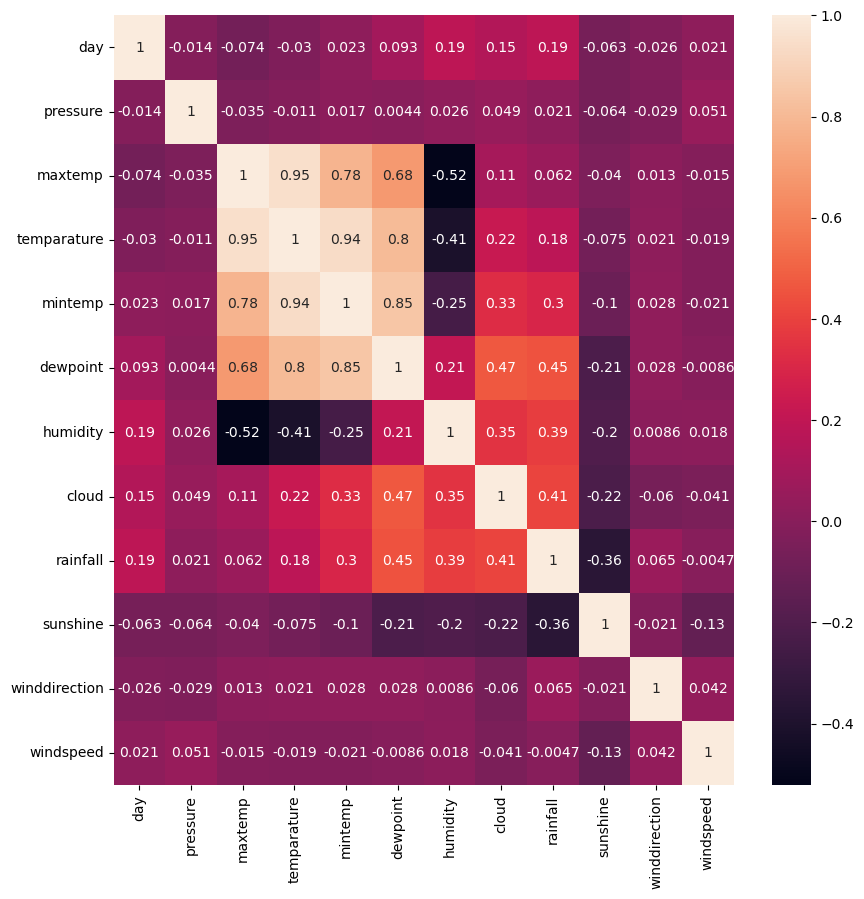

In [95]:
plt.figure(figsize=(10,10))
sn.heatmap(df.corr(),
           annot=True,
           cbar=True)
plt.show()

In [96]:
df.drop(['maxtemp', 'mintemp'], axis=1, inplace=True)
print(df.columns)

Index(['day', 'pressure', 'temparature', 'dewpoint', 'humidity', 'cloud',
       'rainfall', 'sunshine', 'winddirection', 'windspeed'],
      dtype='object')


In [101]:
df.head(20)

,day,pressure,temparature,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1011.973170,15.200201,11.592164,81,38,0,0.999749,165.329601,11.674172
1,2,1014.439975,12.992444,5.330913,61,29,0,1.818250,66.025624,11.084845
2,3,1012.237058,14.135590,7.882965,68,27,0,2.327713,32.618316,17.367720
3,4,1017.198808,15.353618,10.154195,74,6,0,0.650516,341.598793,24.312641
4,5,1013.684661,15.108135,7.694168,62,6,0,8.331949,62.411275,12.821212
5,6,1004.158833,13.554945,8.105881,72,3,0,9.695846,279.047816,23.789979
6,7,1001.769850,16.566787,14.098032,87,22,0,9.611720,304.032186,19.946402
7,8,1012.140685,14.752090,12.543622,88,28,0,0.745506,355.279297,20.444895
8,9,1014.137147,11.012906,7.905674,84,34,0,6.059600,333.468316,18.021541
9,10,1001.908202,17.549933,12.246637,73,22,0,6.659224,212.867204,10.494436


In [121]:
#Removing unnecessary feature -- day
features = df.drop(['day'], axis=1)
print("Removed day as a feature!!")

features = df.drop(['rainfall'], axis=1) #rainfall removed since its the target variable
print("Features made ready for training model.")

Removed day as a feature!!
Features made ready for training model.


In [122]:
target = df.rainfall
print("Created feature and target variable for our model")

Created feature and target variable for our model


### Step 5 : Train Test Split + Standardization

*Train Test Split*:
- Splitting data into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

*80% training, 20% testing*:
- A common split ratio to balance model training and evaluation.

*Standardization*:
- Scaling features to a common range to improve model convergence and performance.

*Oversampling*:
- Creating additional copies of minority class samples to balance class distribution, addressing class imbalance issues.


In [127]:
X_train, X_test, Y_train, Y_test = train_test_split(features,
                                      target,
                                      test_size=0.2,
                                      stratify=target,
                                      random_state=2)

# As the data was highly imbalanced we will
# balance it by adding repetitive rows of minority class.
ros = RandomOverSampler(sampling_strategy='minority',
                        random_state=22)
X, Y = ros.fit_resample(X_train, Y_train)

In [128]:
# Normalize the feature range lead to model performance 
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_test = scaler.transform(X_test)

### Step 6 : Model Training 
    
*Why 3 models,not 1 ?*
- Using multiple models helps compare performance, identify the best approach, and reduce reliance on a single model.

*Models used:*
- *SVC (Support Vector Classifier)*: Effective for high-dimensional data with non-linear relationships.
- *XGB (XGBoost)*: Handles complex interactions and is robust to outliers.
- *Logistic Regression*: Simple, interpretable, and effective for linearly separable data.

In [129]:
models = [LogisticRegression(), 
          SVC(kernel='rbf',probability=True), 
          XGBClassifier()]

for i in range(3):
  models[i].fit(X, Y)

  print(f'{models[i]} : ')

  train_preds = models[i].predict_proba(X)
  print('Training Accuracy : ', metrics.roc_auc_score(Y, train_preds[:,1]))

  val_preds = models[i].predict_proba(X_test)
  print('Validation Accuracy : ', metrics.roc_auc_score(Y_test, val_preds[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.9311844934157486
Validation Accuracy :  0.9043715846994536

SVC(probability=True) : 
Training Accuracy :  0.9681873152378393
Validation Accuracy :  0.9125683060109289

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  

### Step 7 : Model Evaluation
    
*Why model evaluation?*
- To assess model performance, identify areas for improvement, and ensure the model generalizes well to new data.

*Metrics (confusion matrix, precision, recall, etc.):*
- *Confusion matrix*: Table showing true positives, false positives, true negatives, and false negatives.
- *Precision*: Ratio of true positives to total predicted positives (TP / (TP + FP)).
- *Recall*: Ratio of true positives to total actual positives (TP / (TP + FN)).
- Used to evaluate model performance, especially for imbalanced datasets.

*F1 Score*: Harmonic mean of precision and recall (2 * (Precision * Recall) / (Precision + Recall)), balancing both metrics.

*Support*: Number of actual occurrences of each class in the dataset.


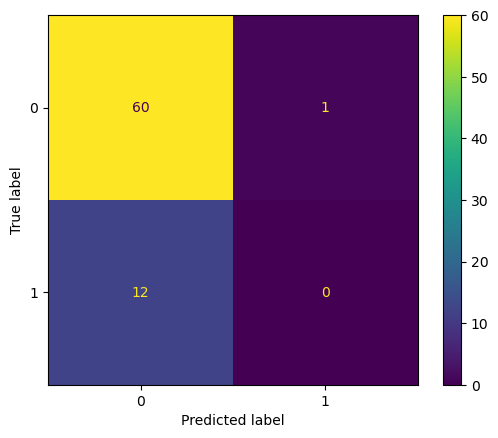

In [133]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics

# Use ConfusionMatrixDisplay.from_estimator instead of plot_confusion_matrix
ConfusionMatrixDisplay.from_estimator(models[2], X_val, Y_val)
plt.show()

In [135]:
print(metrics.classification_report(Y_val,
                                    models[2].predict(X_val)))

              precision    recall  f1-score   support

           0       0.83      0.98      0.90        61
           1       0.00      0.00      0.00        12

    accuracy                           0.82        73
   macro avg       0.42      0.49      0.45        73
weighted avg       0.70      0.82      0.75        73

